In [12]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE, ADASYN, SMOTENC
import shap


In [13]:
df = pd.read_csv("data/train-cat-encoded.csv")
print("Training set size: ", df.shape)
y = df['Will_Buy_EV']
x = df.drop(columns=['Will_Buy_EV'])
x = x.drop(columns=['id', 'Home_Charging_Possible', 'City_Type_Rural', 'Current_Car_Type_Hatchback',
                    'Current_Car_Type_Truck', 'Gender_Male', 'Gender_Female', 'Gender_Other',
                    'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
                    'Charging_Stations_Near_Work', 'Range_Anxiety_Level'])
binary_features = [
    # 'Home_Charging_Possible', 
    'Subsidy_Available', 
    'City_Type_Urban', 'City_Type_Suburban', 
    # 'City_Type_Rural', 
    'Current_Car_Type_Sedan', 'Current_Car_Type_SUV', 
    # 'Current_Car_Type_Hatchback', 
    # 'Current_Car_Type_Truck', 
    # 'Gender_Male', 'Gender_Female', 'Gender_Other'
    ]
print(binary_features)


Training set size:  (668665, 22)
['Subsidy_Available', 'City_Type_Urban', 'City_Type_Suburban', 'Current_Car_Type_Sedan', 'Current_Car_Type_SUV']


In [ ]:
n_splits = 5
total_sample, n_features = x.shape
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
subsetNum = total_sample
subset_x = x.iloc[:subsetNum]
subset_y = y.iloc[:subsetNum]
smote = SMOTENC(
    random_state=42,
    categorical_features=binary_features)
ada = ADASYN(n_neighbors=5, random_state=42)


In [ ]:
X_train_resampled, y_train_resampled = smote.fit_resample(subset_x, subset_y)
model = XGBClassifier(
    n_estimators=200,      # number of boosting rounds (trees)
    max_depth=4,           # tree depth
    learning_rate=0.15,     # shrinkage per round
    subsample=0.75,         # row sampling per tree
    colsample_bytree=0.8,  # feature sampling per tree
    eval_metric='logloss'
)
model.fit(X_train_resampled, y_train_resampled)


==========XGBoost Cross Validation Training Loop==========

========== FOLD 1 ==========
Fold 1 | AUC: 0.9283
F1: 0.6811 | Recall: 0.7766 | Precision: 0.6066


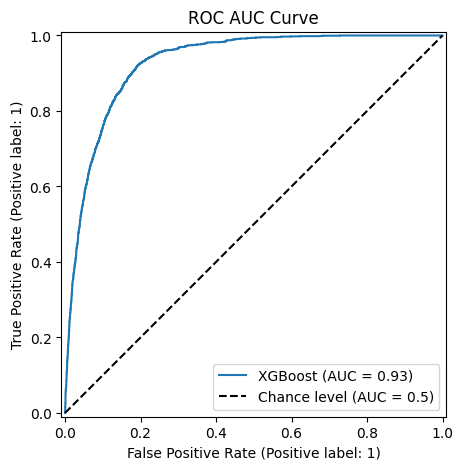

Background dataset has 66096 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=66096 when initializing the masker.
100%|===================| 9982/10000 [00:35<00:00]        

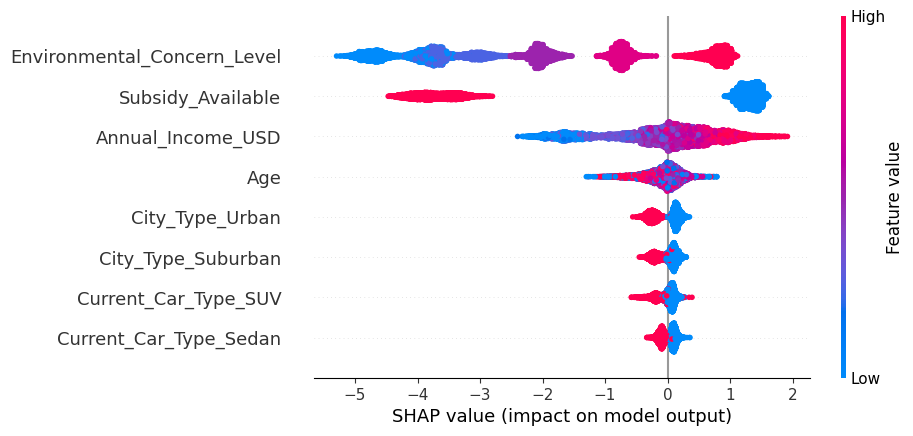

Finished Fold 1

========== FOLD 2 ==========
Fold 2 | AUC: 0.9336
F1: 0.6952 | Recall: 0.7745 | Precision: 0.6307


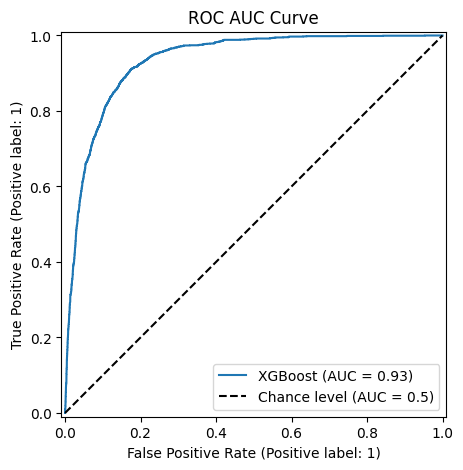

Background dataset has 66098 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=66098 when initializing the masker.
 99%|===================| 9902/10000 [00:34<00:00]        

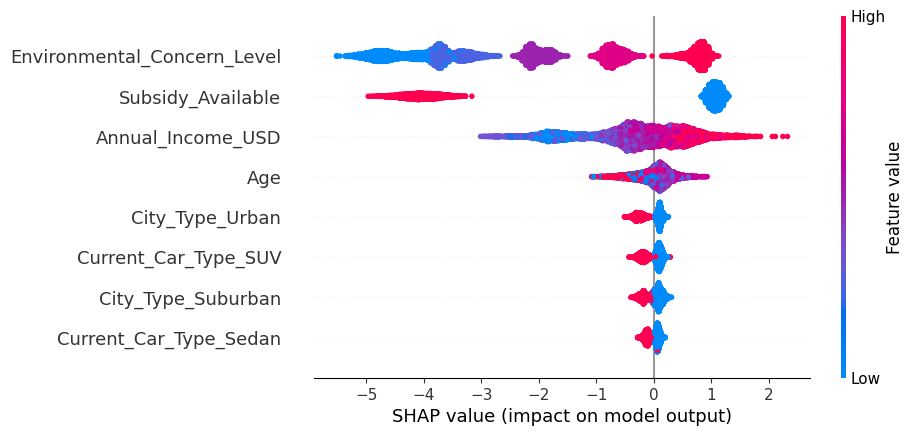

Finished Fold 2

========== FOLD 3 ==========
Fold 3 | AUC: 0.9370
F1: 0.7038 | Recall: 0.7917 | Precision: 0.6335


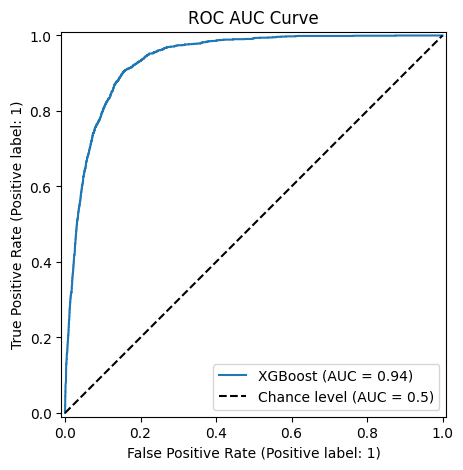

Background dataset has 66098 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=66098 when initializing the masker.
 98%|===================| 9848/10000 [00:35<00:00]        

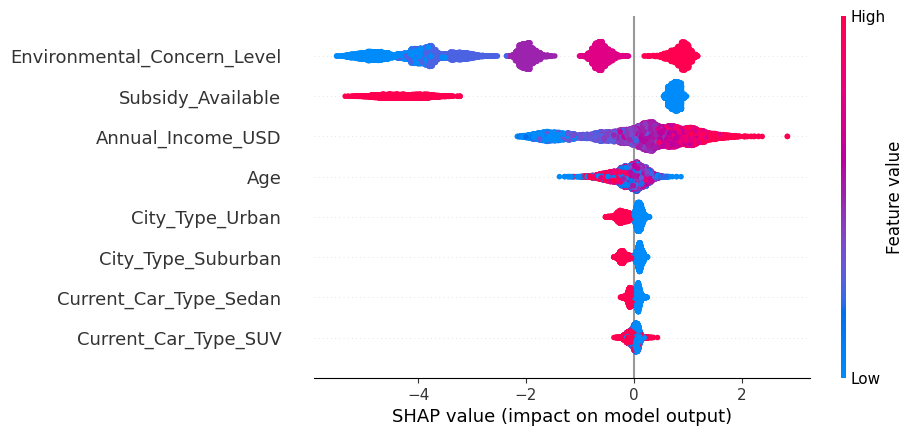

Finished Fold 3

========== FOLD 4 ==========
Fold 4 | AUC: 0.9326
F1: 0.6867 | Recall: 0.7750 | Precision: 0.6165


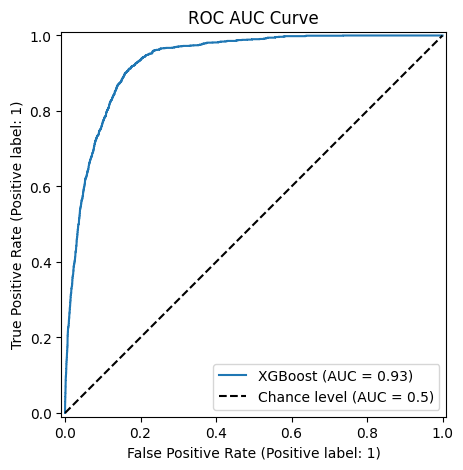

Background dataset has 66098 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=66098 when initializing the masker.
 99%|===================| 9866/10000 [00:34<00:00]        

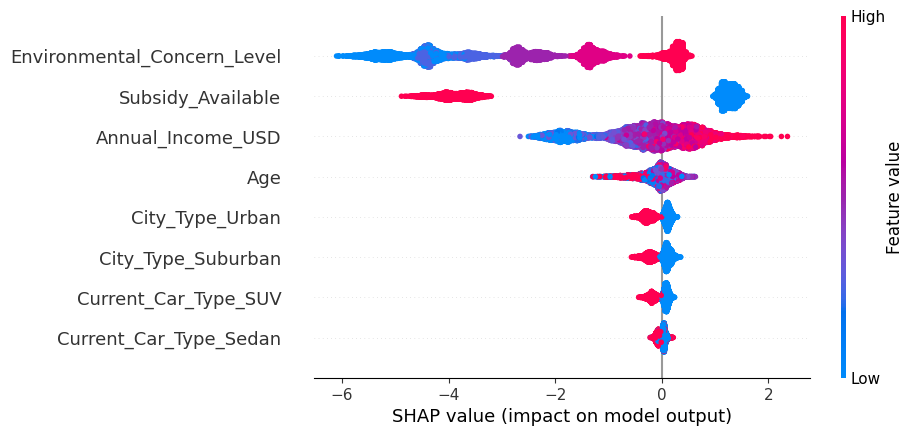

Finished Fold 4

========== FOLD 5 ==========
Fold 5 | AUC: 0.9341
F1: 0.6957 | Recall: 0.7722 | Precision: 0.6330


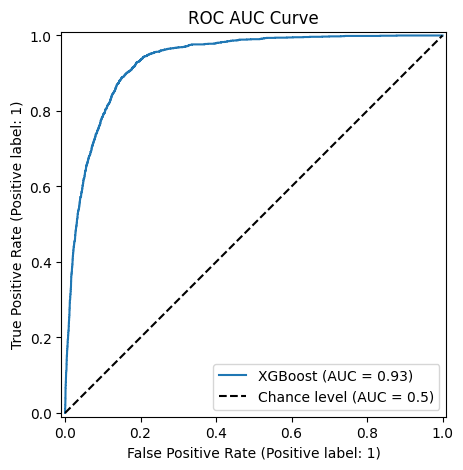

Background dataset has 66098 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=66098 when initializing the masker.
 99%|===================| 9858/10000 [00:33<00:00]        

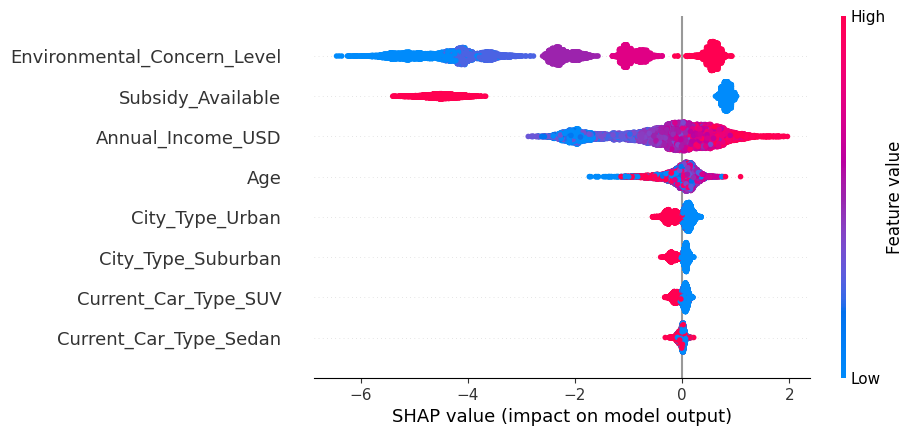

Finished Fold 5
Avg AUC: 0.9331
Avg F1: 0.6925
Avg Recall: 0.7780
Avg Precision: 0.6241
Std AUC: 0.002826280043805913


In [15]:
xgbAucList = []
xgbF1List = []
xgbRecallList = []
xgbPrecisionList = []

print("==========XGBoost Cross Validation Training Loop==========")
for fold, (train_idx, val_idx) in enumerate(skf.split(subset_x, subset_y)):
    print(f"\n========== FOLD {fold + 1} ==========")
    
    # 1. Split data (using .iloc if X/y are pandas DataFrames)
    X_train, X_val = subset_x.iloc[train_idx], subset_x.iloc[val_idx]
    y_train, y_val = subset_y.iloc[train_idx], subset_y.iloc[val_idx]
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    # X_train_resampled, y_train_resampled = ada.fit_resample(X_train, y_train)

    model = XGBClassifier(
    n_estimators=200,      # number of boosting rounds (trees)
    max_depth=4,           # tree depth
    learning_rate=0.15,     # shrinkage per round
    subsample=0.75,         # row sampling per tree
    colsample_bytree=0.8,  # feature sampling per tree
    eval_metric='logloss'
)
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, y_prob)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print(f"Fold {fold + 1} | AUC: {auc:.4f}")
    print(f"F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")

    # ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name="XGBoost")
    ax.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
    ax.set_title("ROC AUC Curve")
    ax.legend(loc="lower right")
    plt.show()

    # explainer = shap.Explainer(model, X_train_resampled)
    # shap_values = explainer(X_val)

    # # 4. Plot the Beeswarm summary chart
    # shap.plots.beeswarm(shap_values)

    xgbAucList.append(auc)
    xgbF1List.append(f1)
    xgbRecallList.append(recall)
    xgbPrecisionList.append(precision)
              
    print(f"Finished Fold {fold + 1}")

print(f"Avg AUC: {(sum(xgbAucList) / n_splits):.4f}")
print(f"Avg F1: {(sum(xgbF1List) / n_splits):.4f}")
print(f"Avg Recall: {(sum(xgbRecallList) / n_splits):.4f}")
print(f"Avg Precision: {(sum(xgbPrecisionList) / n_splits):.4f}")
print(f"Std AUC: {np.std(xgbAucList)}")


### Without oversampling (10000 samples)
- Avg AUC: 0.7961
- Avg F1: 0.6768
- Avg Recall: 0.6476
- Avg Precision: 0.7091
- Std AUC: 0.011227993955145489

### With SMOTE 
- (50000 samples)
- Avg AUC: 0.9380
- Avg F1: 0.6928
- Avg Recall: 0.6803
- Avg Precision: 0.7061
- Std AUC: 0.0027307035663074416

- (100000 samples)
- Avg AUC: 0.9366
- Avg F1: 0.7012
- Avg Recall: 0.7416
- Avg Precision: 0.6650
- Std AUC: 0.001856941113581715

(200000 samples)
- Avg AUC: 0.9399
- Avg F1: 0.6997
- Avg Recall: 0.6903
- Avg Precision: 0.7095
- Std AUC: 0.0008880157870868589

(500000 samples)
- Avg AUC: 0.9402
- Avg F1: 0.6996
- Avg Recall: 0.6896
- Avg Precision: 0.7098
- Std AUC: 0.0008942851500033605

### With ADASYN 
- (50000 samples)
- Avg AUC: 0.9379
- Avg F1: 0.6930
- Avg Recall: 0.6819
- Avg Precision: 0.7048
- Std AUC: 0.0026846216264028214

In [17]:
test_df = pd.read_csv("data/test-cat-encoded.csv")
id_df = test_df[['id']]
test_df = test_df.drop(columns=['id', 'Home_Charging_Possible', 'City_Type_Rural', 'Current_Car_Type_Hatchback',
                    'Current_Car_Type_Truck', 'Gender_Male', 'Gender_Female', 'Gender_Other',
                    'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
                    'Charging_Stations_Near_Work', 'Range_Anxiety_Level'])
test_pred = model.predict_proba(test_df)[:, 1]
test_pred = pd.DataFrame(test_pred)
submission_df = pd.concat([id_df, test_pred], axis=1)
submission_df.rename(columns={submission_df.columns[1]: "Will_Buy_EV"}, inplace=True)
print(submission_df.columns)
submission_df.to_csv("data/submission3.csv", index=False)


Index(['id', 'Will_Buy_EV'], dtype='str')
